In [1]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "DeepUnitMatch"))
sys.path = list(set(sys.path))
from testing.test import *
import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns


def paired_violin_plot(
    M,
    labels=None,
    colors=None,
    ylabel="Value",
    figsize=(6, 5),
    jitter=0.06,
    violin_width=0.6,
    show_violin=True,
    show_points=True,
    show_mean=True,
    show_sem=True,
    alpha_lines=0.35,
    comparisons="adjacent",   # "adjacent", "all", or list of tuples
):
    """
    Parameters
    ----------
    M : ndarray
        Shape = (n_models, n_samples)

    labels : list of str
        Labels for each model.

    colors : list
        List of matplotlib colours.

    comparisons :
        "adjacent" -> compare neighbouring models
        "all" -> compare every pair
        [(0,2),(1,3)] -> custom comparisons
    """

    M = np.asarray(M)

    if M.ndim != 2:
        raise ValueError("M must have shape (n_models, n_samples).")

    n_models, n_samples = M.shape

    if labels is None:
        labels = [f"Model {i+1}" for i in range(n_models)]

    if colors is None:
        colors = sns.color_palette("tab10", n_models)

    x = np.arange(n_models)

    fig, ax = plt.subplots(figsize=figsize)

    # ---------------------------------------------------
    # Violin plots
    # ---------------------------------------------------
    if show_violin:
        vp = ax.violinplot(
            M.T,
            positions=x,
            widths=violin_width,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )

        for body, colour in zip(vp["bodies"], colors):
            body.set_facecolor(colour)
            body.set_edgecolor("none")
            body.set_alpha(0.25)

    # ---------------------------------------------------
    # Connecting lines
    # ---------------------------------------------------
    for i in range(n_samples):
        xx = x + np.random.uniform(-jitter/3, jitter/3, n_models)
        ax.plot(xx, M[:, i],
                color="0.75",
                lw=1,
                alpha=alpha_lines,
                zorder=1)

    # ---------------------------------------------------
    # Scatter points
    # ---------------------------------------------------
    if show_points:
        for k in range(n_models):
            xx = x[k] + np.random.uniform(-jitter, jitter, n_samples)

            ax.scatter(
                xx,
                M[k],
                s=35,
                color=colors[k],
                edgecolor="none",
                zorder=3
            )

    # ---------------------------------------------------
    # Mean ± SEM
    # ---------------------------------------------------
    means = M.mean(axis=1)
    sem = M.std(axis=1, ddof=1) / np.sqrt(n_samples)

    if show_sem:
        ax.errorbar(
            x,
            means,
            yerr=sem,
            fmt="none",
            color="black",
            lw=2,
            zorder=4
        )

    if show_mean:
        ax.scatter(
            x,
            means,
            s=70,
            facecolor="white",
            edgecolor="black",
            linewidth=2,
            zorder=5
        )

    # ---------------------------------------------------
    # Significance tests
    # ---------------------------------------------------
    if comparisons is not None:

        if comparisons == "adjacent":
            comparisons = [(i, i + 1) for i in range(n_models - 1)]

        elif comparisons == "all":
            comparisons = [
                (i, j)
                for i in range(n_models)
                for j in range(i + 1, n_models)
            ]

        ymax = np.max(M)
        yrange = np.ptp(M)

        if yrange == 0:
            yrange = 1

        h = 0.05 * yrange
        base = ymax + 0.05 * yrange

        for k, (i, j) in enumerate(comparisons):

            p = ttest_rel(M[i], M[j]).pvalue

            y = base + k * (2 * h)

            if p < 0.05:
                ax.plot(
                    [i, i, j, j],
                    [y, y + h, y + h, y],
                    color="black",
                    lw=1.5
                )

                ax.text(
                    (i + j) / 2,
                    y + h,
                    f"p = {p:.3g}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    style="italic"
                )

    # ---------------------------------------------------
    # Formatting
    # ---------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation = 45)
    ax.set_ylabel(ylabel)

    sns.despine()

    ax.set_xlim(-0.5, n_models - 0.5)
    ax.set_ylim(bottom=0)

    plt.tight_layout()

    return fig, ax

In [12]:
models = ["DeepUnitMatch",
        #   "UMPy", 
        #   "DUM_maxdist=20", "DUM_maxdist=50", "DUM_maxdist=100", "DUM_maxdist=inf", 
        #   "UMPy_maxdist=20", "UMPy_maxdist=50", "UMPy_maxdist=100", "UMPy_maxdist=inf",
        #   "DUM_W_ij=1","DUM_W_ij=5","DUM_W_ij=10","DUM_W_ij=15","DUM_W_ij=20", 
          "n_output=8_after_ae_and_finetune", "n_output=32_after_ae_and_finetune", "n_output=128_after_ae_and_finetune", "n_output=256_after_ae_and_finetune", 
        #   "EMD"
            ]

shared_columns = ["mouse", "probe", "loc", "day1", "day2", "r1", "r2", "delta_days"]

df = pd.read_csv(
    os.path.join(RESULTS_DIR, f"UM Probabilities_{models[0]}_results_temp.csv")
).drop_duplicates()
keep = df["N"] > 19

def rename_df(df, shared_columns, model):
    return df.rename(columns={col: f"{col}_{model}" for col in df.columns if col not in shared_columns})

df = rename_df(df, shared_columns, models[0])

for model in models[1:]:
    df_new = pd.read_csv(
        os.path.join(RESULTS_DIR, f"UM Probabilities_{model}_results_temp.csv")
    ).drop_duplicates()
    df_new = rename_df(df_new, shared_columns, model)
    df = df.merge(df_new, on=shared_columns)
    keep = keep | (df_new[f"N_{model}"] > 19)
df = df.loc[keep]

metric_to_plot = 'AUCisi'
# metric_to_plot = 'N'

M = []
for model in models:
    avg_metric_by_mouse = df.groupby("mouse")[f"{metric_to_plot}_{model}"].mean()
    M.append(avg_metric_by_mouse.values)

M = np.asarray(M)
np.shape(M)

(5, 13)

(0.7, 1.0841513188519059)

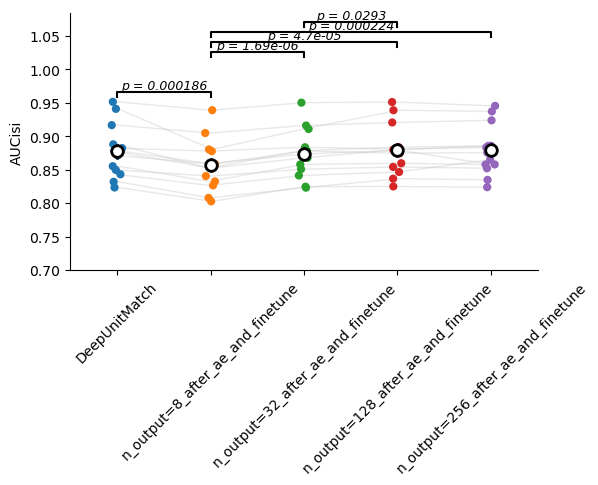

In [13]:
fig, ax = paired_violin_plot(
    M,
    labels=models,
    ylabel=metric_to_plot,
    comparisons="all",   # or "all" or [(0,3), (1,4)]
    show_violin = False,
    colors = None
)
ax.set_ylim(bottom=0.7)